Thinking...
Thinking...
Thinking...

File metadata:
  Job: Seis
  Sample Rate: 1651.6129032258063
  Start Time: Wed Jul 22 2026 10:56:33 GMT-0700 (Pacific Daylight Time)


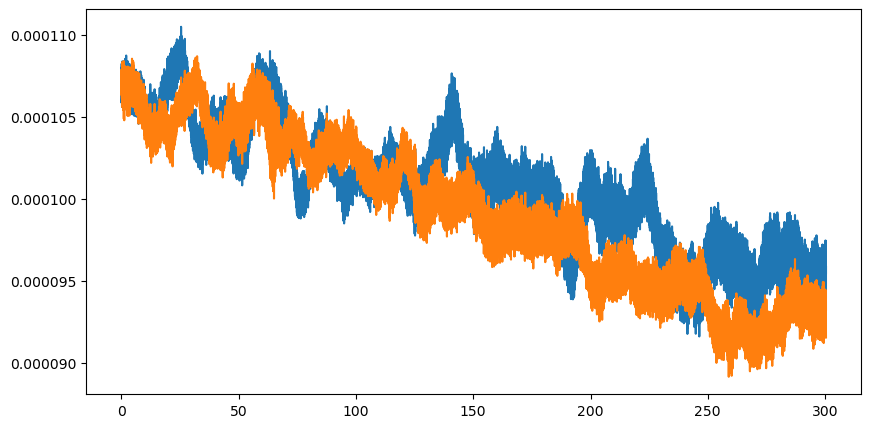

In [150]:
print("Thinking...")
import warnings
import pandas as pd                    # For reading CSV files into tables
import numpy as np                     # For numerical calculations
print("Thinking...")
from scipy import signal               # For the Welch PSD / spectral analysis
from matplotlib import pyplot as plt   # For creating plots
import os
print("Thinking...")
import tkinter as tk
from tkinter import filedialog
from matplotlib import gridspec
from matplotlib.colors import LogNorm

warnings.simplefilter('ignore')


data_file_path = r"C:\Users\shrey\Downloads\seis_2026-07-22_outsidephase_1.34mpointedtowardslvea.csv"


Forty_T_First = False     ## Is the 40T on channels 1 and 2
pre_amps=False


metadata = {}
with open(data_file_path, 'r') as f:
    for _ in range(5):
        line = f.readline().strip()
        if ':' in line:
            key, value = line.split(':', 1)
            metadata[key.strip()] = value.strip()

print("\nFile metadata:")
for key, value in metadata.items():
    print(f"  {key}: {value}")

sample_rate = float(metadata["Sample Rate"])


## -------------- Read the seismic data columns --------------- ##

raw_data = pd.read_csv(data_file_path, skiprows=5, delimiter=',')


if Forty_T_First == True:
    raw_data.columns = ["Sample", "Time (s)", 
                        "40T N", "40T Z", 
                        "3T N", "3T Z", 
                        "blank"]
else:
    raw_data.columns = ["Sample", "Time (s)", 
                        "3T N", "3T Z", 
                        "40T N", "40T Z", 
                        "blank"]


## --- Apply calibration factor (Volts → meters per second) --- ##
if pre_amps:
    calibration = (0.0125e-1) / 21
else:
    calibration = 0.0125e-1

N_40T   = raw_data["40T N"] * calibration   # 
Z_40T   = raw_data["40T Z"] * calibration   # 
N_3T   = raw_data["3T N"]  * calibration   # 
Z_3T   = raw_data["3T Z"]  * calibration   # 
time  = raw_data["Time (s)"]

# fs = sample_rate  # Sampling frequency (Hz)
# t = np.arange(0, 300, 1/fs)  # 2 seconds duration
# # Signal 1: Core frequency components at 50 Hz and 120 Hz
# Z_40T = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 120 * t)
# Z_40T += np.random.normal(0, 0.5, len(t))

# # Signal 2: Deliberate 90-degree (pi/2) phase shift at 50 Hz 
# # and a 45-degree (pi/4) shift at 120 Hz, plus noise
# Z_3T = np.sin(2 * np.pi * 50 * t + np.pi/2) + np.sin(2 * np.pi * 120 * t + np.pi/4)
# Z_3T += np.random.normal(0, 0.5, len(t))

plt.figure(figsize=(10, 5))
plt.plot(time, Z_40T)
plt.plot(time, Z_3T)


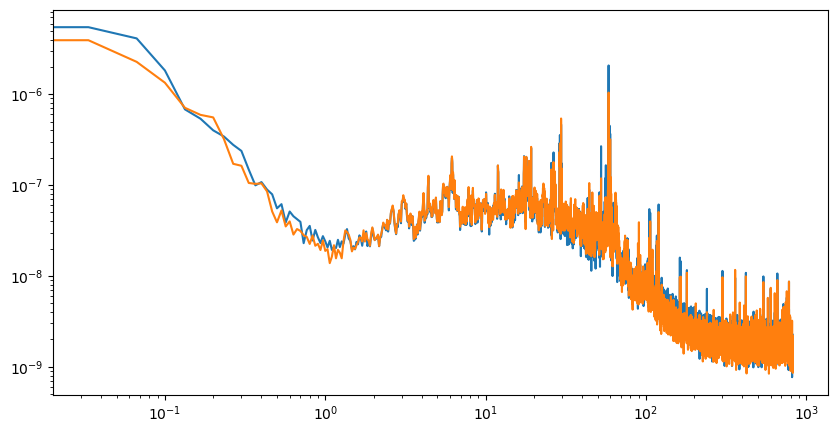

In [151]:
def welch_asd(data, sr):
        """
        Run Welch's method on `data` sampled at `sr` Hz.
        Returns (frequencies, amplitude_spectral_density).
        """
        data = np.asarray(data)   # Ensure it's a plain numpy array

        frequencies, power = signal.welch(
            data,
            sr,
            window   = 'hamming',
            nperseg  = int(sr * fft_window_s),                  ## nperseg:  number of samples per FFT window
            noverlap = int(round(sr * (overlap * 0.01) ) )      ## noverlap: number of samples shared between adjacent windows
        )
        
        # ASD = square root of PSD
        return frequencies, np.sqrt(power)

fft_window_s = 30
overlap = 50

freq1, Z_40_asd = welch_asd(Z_40T, sample_rate)
freq2, Z_3_asd = welch_asd(Z_3T, sample_rate)

freq1, N_40_asd = welch_asd(N_40T, sample_rate)
freq2, N_3_asd = welch_asd(N_3T, sample_rate)


plt.figure(figsize=(10, 5))
plt.yscale('log')
plt.xscale('log')
plt.plot(freq1, Z_40_asd)
plt.plot(freq2, Z_3_asd)


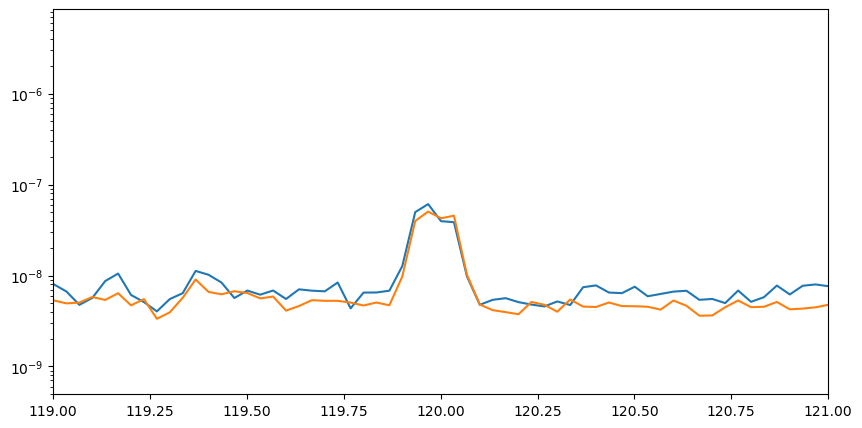

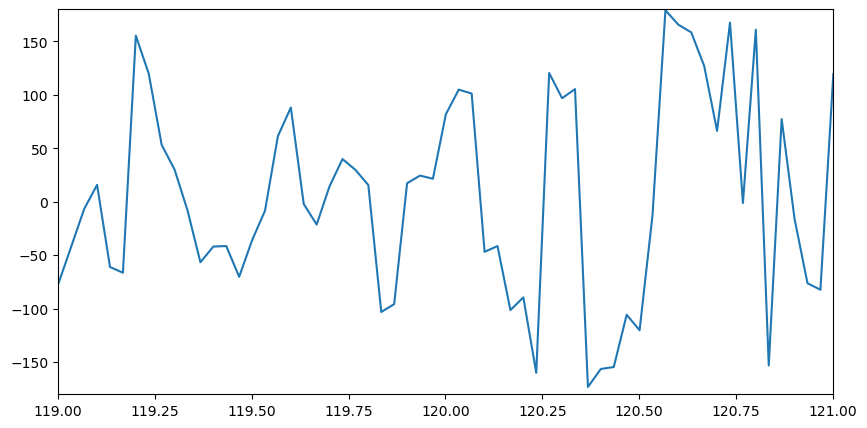

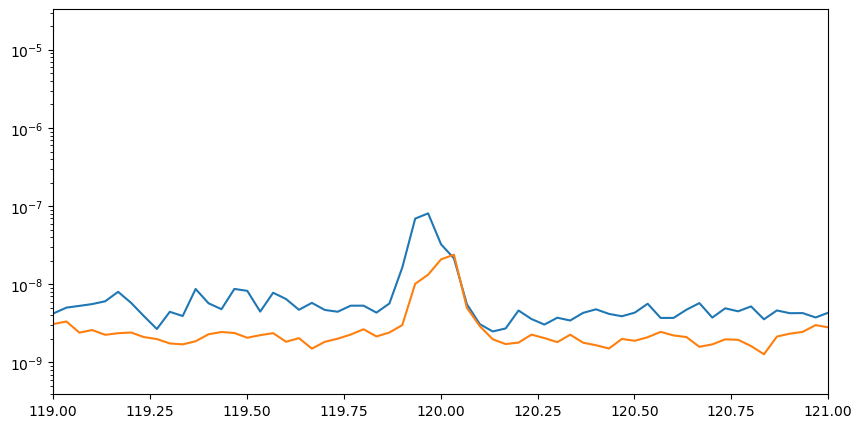

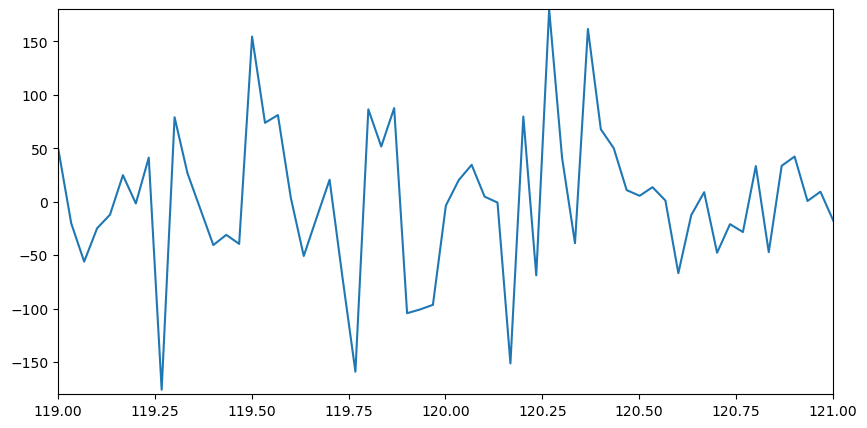

In [152]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import csd


frequencies, power_density = csd(Z_40T, Z_3T, fs=sample_rate,
                                window   = 'hamming',
                                nperseg  = int(sample_rate * fft_window_s),                  ## nperseg:  number of samples per FFT window
                                noverlap = int(round(sample_rate * (overlap * 0.01) ) )      ## noverlap: number of samples shared between adjacent windows
                                   )

phase_spectrum = np.angle(power_density)

phase_spectrum_deg = np.rad2deg(phase_spectrum)


frequencies, power_density_n = csd(N_40T, N_3T, fs=sample_rate,
                                window   = 'hamming',
                                nperseg  = int(sample_rate * fft_window_s),                  ## nperseg:  number of samples per FFT window
                                noverlap = int(round(sample_rate * (overlap * 0.01) ) )      ## noverlap: number of samples shared between adjacent windows
                                   )

phase_spectrum_n = np.angle(power_density_n)

phase_spectrum_deg_n = np.rad2deg(phase_spectrum_n)


# Plotting the Phase Spectrum

plt.figure(figsize=(10, 5))
plt.xlim(119,121)
plt.yscale('log')
#plt.xscale('log')
plt.plot(freq1, Z_40_asd)
plt.plot(freq2, Z_3_asd)

plt.figure(figsize=(10, 5))
plt.xlim(119,121)
#plt.xscale('log')
plt.ylim(-180,180)
plt.plot(frequencies, phase_spectrum_deg, label='Phase Difference')

plt.figure(figsize=(10, 5))
plt.xlim(119,121)
plt.yscale('log')
#plt.xscale('log')
plt.plot(freq1, N_40_asd)
plt.plot(freq2, N_3_asd)

plt.figure(figsize=(10, 5))
plt.xlim(119,121)
#plt.xscale('log')
plt.ylim(-180,180)
plt.plot(frequencies, phase_spectrum_deg_n, label='Phase Difference')

# plt.figure(figsize=(10, 5))
# plt.xlim(1e-2,1e3)
# plt.yscale('log')
# plt.xscale('log')
# plt.plot(freq1, Z_40_asd)
# plt.plot(freq2, Z_3_asd)
# plt.plot(frequencies, phase_spectrum_deg, label='Phase Difference')


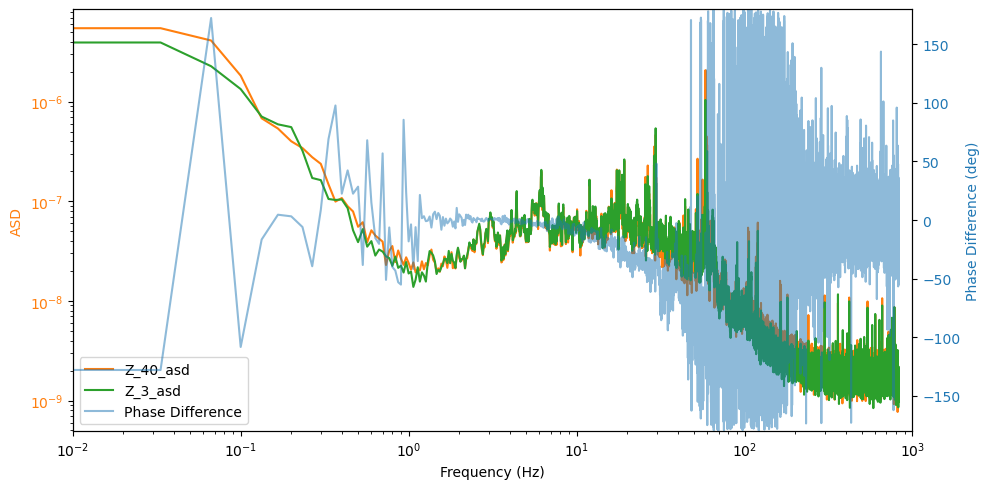

In [153]:
import matplotlib.pyplot as plt

#vibecoded display lol

# 1. Initialize the figure and the first axis (ASD - Left Y-axis)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Set shared X-axis limits and logarithmic scale
ax1.set_xlim(1e-2, 1e3)
ax1.set_xscale('log')

# Configure Left Y-axis (ASD - Logarithmic scale)
ax1.set_yscale('log')
ax1.set_ylabel('ASD', color='tab:orange')
line1 = ax1.plot(freq1, Z_40_asd, color='tab:orange', label='Z_40_asd')
line2 = ax1.plot(freq2, Z_3_asd, color='tab:green', label='Z_3_asd')
ax1.tick_params(axis='y', labelcolor='tab:orange')

# 2. Create the second axis sharing the X-axis (Phase - Right Y-axis)
ax2 = ax1.twinx()

# Configure Right Y-axis (Phase Difference - Linear scale)
ax2.set_ylim(-180, 180)
ax2.set_ylabel('Phase Difference (deg)', color='tab:blue')
line3 = ax2.plot(frequencies, phase_spectrum_deg, color='tab:blue', label='Phase Difference',alpha=0.5)
ax2.tick_params(axis='y', labelcolor='tab:blue')

# 3. Combine legends from both axes into one box
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower left')

# 4. Final adjustments and display
ax1.set_xlabel('Frequency (Hz)')
fig.tight_layout()
plt.show()


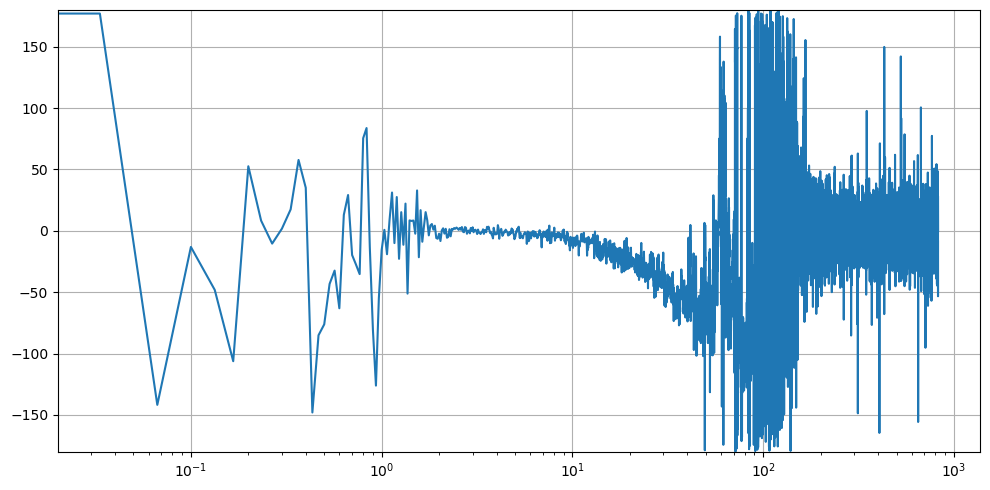

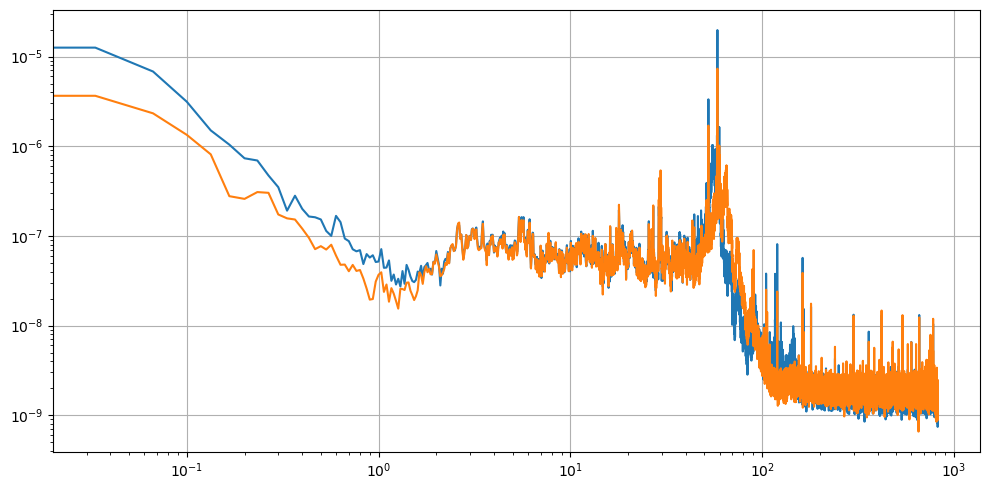

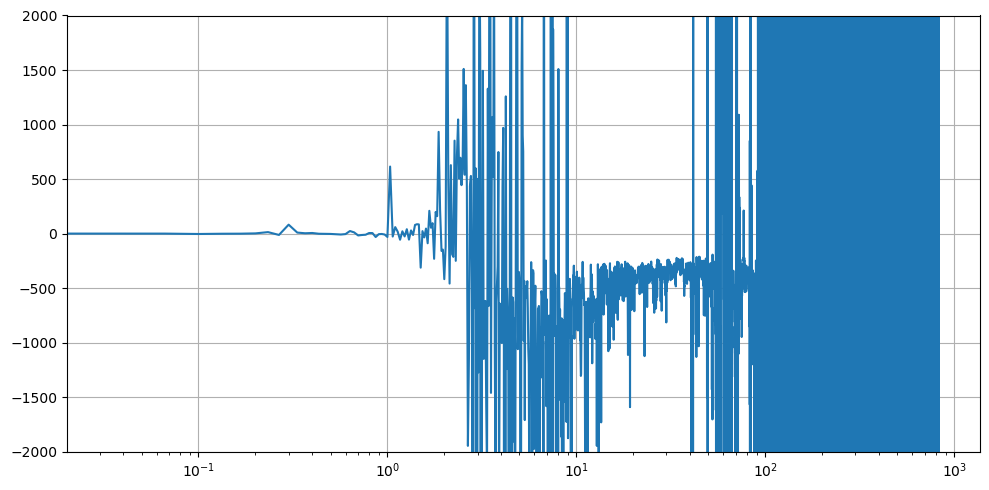

In [157]:
distance = 1.34 #meters
vel = (frequencies * distance * 360) / phase_spectrum_deg_n



plt.figure(figsize=(10, 5))
#plt.xlim(1e-2,1e3)
plt.xscale('log')
#plt.xlim(58,60)
plt.ylim(-180,180)
plt.plot(frequencies, phase_spectrum_deg_n, label='Phase Difference')
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(10, 5))
#plt.xlim(1e-2,1e3)
plt.yscale('log')
plt.xscale('log')
#plt.xlim(58,60)
plt.plot(freq1, N_40_asd)
plt.plot(freq2, N_3_asd)
plt.grid(True)
plt.tight_layout()


plt.figure(figsize=(10, 5))
#plt.xlim(1e-2,1e3)
plt.xscale('log')
plt.ylim(-2000,2000)
#plt.xlim(58,60)
plt.plot(frequencies, vel, label='Velocity')
plt.grid(True)
plt.tight_layout()

In [149]:
band = (frequencies >= 56) & (frequencies <= 61)
    
average_vel = np.mean(vel[band])
print(average_vel)

average_phase = np.mean(phase_spectrum_deg[band])
vel1 = (60 * distance * 360) / 90
print(vel1)

-1.7951411221100715
321.6
